<a href="https://colab.research.google.com/github/kapilk75/SmartWater01/blob/main/demoSparc02_07042026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### =========================================================
### FULL PIPELINE: Time-Series + Visualization + Map
### =========================================================

In [30]:
!pip -q install openpyxl plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

# ---------------------------
# Load dataset
# ---------------------------
url = "https://raw.githubusercontent.com/kapilk75/SmartWater01/main/workshop_250_rows.xlsx"
df = pd.read_excel(url)

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (250, 139)


,ec5_uuid_survey,created_at_survey,uploaded_at_survey,created_by_survey,title_survey,1_Date_Autoset_click,lat_2_Location_Click_Upd,long_2_Location_Click_Upd,accuracy_2_Location_Click_Upd,UTM_Northing_2_Location_Click_Upd,...,created_at,uploaded_at,created_by,title,112_Date_Autoset_cli,113_Time_Autoset_cli,114_Sample_No,115_Presence_of_Ecol,116_Presence_of_Tota,117_Photo_of_Bio_Kit
0,33cc0843-2087-4ad5-99c5-e3ade8a26322,2025-05-22T07:15:26.000Z,2025-05-22T10:13:46.000Z,na22b074@smail.iitm.ac.in,Tk22051239,22/05/2025,12.983787,80.241864,4.0,1435465.0,...,2025-05-22T09:58:46.000Z,2025-05-22T10:13:50.000Z,na22b074@smail.iitm.ac.in,Sample 6,22/05/2025,15:28:25,Sample 6,Yes,Yes,287e9de1-8031-4d38-bfc2-162d9b7f216a_174790792...
1,23f7db67-a94f-4490-890a-9c3cfe5ae6a6,2025-05-22T06:47:43.000Z,2025-05-22T09:59:26.000Z,na22b084@smail.iitm.ac.in,IJ22051150,22/05/2025,12.981735,80.240876,4.0,1435238.0,...,2025-05-22T09:53:58.000Z,2025-05-22T09:59:29.000Z,na22b084@smail.iitm.ac.in,Sample 8,22/05/2025,15:23:42,Sample 8,No,No,2a22a5f6-99aa-491a-9a9c-2a3e362c813f_174790763...
2,fb708e0b-da63-4a17-8167-019c755773e2,2025-05-21T07:06:42.000Z,2025-05-22T09:59:02.000Z,na22b084@smail.iitm.ac.in,IJ21051130,21/05/2025,12.943463,80.208609,4.0,1431016.0,...,2025-05-22T09:36:28.000Z,2025-05-22T09:59:06.000Z,na22b084@smail.iitm.ac.in,Sample 1,22/05/2025,15:05:41,Sample 1,No,No,8ffa2528-7723-469f-b74d-adb0c504a54a_174790658...
3,e530531d-8173-40fd-8c22-d48287164577,2025-05-21T07:09:43.000Z,2025-05-22T09:58:39.000Z,na22b084@smail.iitm.ac.in,IJ21051230,21/05/2025,12.967963,80.207516,4.0,1433726.0,...,2025-05-22T09:39:14.000Z,2025-05-22T09:58:42.000Z,na22b084@smail.iitm.ac.in,Sample 2,22/05/2025,15:08:23,Sample 2,No,No,e187d0e5-2d99-4b87-b020-7c197569b4b9_174790681...
4,3ebcb3a2-2f47-4b9b-861d-858ab00a8554,2025-05-05T12:21:46.000Z,2025-05-08T14:26:27.000Z,rabinrajanj@gmail.com,RR05051745,2025-05-05 00:00:00,8.563460,76.951780,13.0,947135.0,...,2025-05-08T14:26:12.000Z,2025-05-08T14:26:31.000Z,rabinrajanj@gmail.com,Sample 1,08/05/2025,19:55:49,Sample 1,No,No,d6b6e674-7c22-4e23-abce-22d1e7446313_174671436...


In [31]:
# =========================================================
# STEP 1: CREATE TIME SERIES (IMPORTANT)
# =========================================================

# Create synthetic timestamp if not present

df["timestamp"] = pd.date_range(
    start="2025-01-01",
    periods=len(df),
    freq="h"   # Use 'h' instead of 'H'
)

# Sort by time
df = df.sort_values("timestamp")
print(df.head())
for col in df.columns:
  print(col, "\t",df[col].count());

                        ec5_uuid_survey         created_at_survey  \
0  33cc0843-2087-4ad5-99c5-e3ade8a26322  2025-05-22T07:15:26.000Z   
1  23f7db67-a94f-4490-890a-9c3cfe5ae6a6  2025-05-22T06:47:43.000Z   
2  fb708e0b-da63-4a17-8167-019c755773e2  2025-05-21T07:06:42.000Z   
3  e530531d-8173-40fd-8c22-d48287164577  2025-05-21T07:09:43.000Z   
4  3ebcb3a2-2f47-4b9b-861d-858ab00a8554  2025-05-05T12:21:46.000Z   

         uploaded_at_survey          created_by_survey title_survey  \
0  2025-05-22T10:13:46.000Z  na22b074@smail.iitm.ac.in   Tk22051239   
1  2025-05-22T09:59:26.000Z  na22b084@smail.iitm.ac.in   IJ22051150   
2  2025-05-22T09:59:02.000Z  na22b084@smail.iitm.ac.in   IJ21051130   
3  2025-05-22T09:58:39.000Z  na22b084@smail.iitm.ac.in   IJ21051230   
4  2025-05-08T14:26:27.000Z      rabinrajanj@gmail.com   RR05051745   

  1_Date_Autoset_click  lat_2_Location_Click_Upd  long_2_Location_Click_Upd  \
0           22/05/2025                 12.983787                  80.241864   


In [38]:
### Get FULL Feature List (Run This)
columns = df.columns.tolist()

print(f"Total Features: {len(columns)}\n")

for i, col in enumerate(columns, 1):
    print(f"{i:03d} | {col}")

Total Features: 140

001 | ec5_uuid_survey
002 | created_at_survey
003 | uploaded_at_survey
004 | created_by_survey
005 | title_survey
006 | 1_Date_Autoset_click
007 | lat_2_Location_Click_Upd
008 | long_2_Location_Click_Upd
009 | accuracy_2_Location_Click_Upd
010 | UTM_Northing_2_Location_Click_Upd
011 | UTM_Easting_2_Location_Click_Upd
012 | UTM_Zone_2_Location_Click_Upd
013 | 3_Informed_Consent_I
014 | 4_Sample_ID_Example_
015 | 5_Time_Autoset_click
016 | 6_Type_of_Water_Samp
017 | 7_Photo_of_Street_Ov
018 | 8_Photo_of_House_and
019 | 9_Photo_of_House_Gat
020 | 10  Name of respondent
021 | 11_Mobile_Number
022 | 12_Respondent Email ID ( Mostly Empty)
023 | 13_Gender
024 | 14_Age_Group
025 | 15_Position in your family
026 | 16_Highest educational qualification
027 | 17_Number of children under the age of 5 in your home
028 | 18_Time (Autoset; click next) 
029 | 19_Time (Autoset; click next)
030 | 20_Where do they fetch the glass of drinking water from?
031 | 21_If others (specify)
03

In [42]:
# 2. Export Features (Very Useful)
feature_df = pd.DataFrame({
    "Index": range(1, len(columns)+1),
    "Feature_Name": columns
})

feature_df.to_csv("dataset_features.csv", index=False)
feature_df

,Index,Feature_Name
0,1,ec5_uuid_survey
1,2,created_at_survey
2,3,uploaded_at_survey
3,4,created_by_survey
4,5,title_survey
...,...,...
135,136,114_Sample_No
136,137,115_Presence_of_Ecol
137,138,116_Presence_of_Tota
138,139,117_Photo_of_Bio_Kit


In [43]:
# 3. Proper Feature Categorization (IMPORTANT)

feature_groups = {
    "Physico-Chemical": [],
    "Sensor Signals": [],
    "Derived Features": [],
    "Temporal": [],
    "Categorical": [],
    "Other": []
}

for col in df.columns:
    c = col.lower()

    if any(k in c for k in ["ph", "tds", "turbidity", "conductivity", "do", "temp"]):
        feature_groups["Physico-Chemical"].append(col)

    elif any(k in c for k in ["sensor", "mq", "raw", "signal", "value"]):
        feature_groups["Sensor Signals"].append(col)

    elif any(k in c for k in ["index", "score", "ratio", "wqi"]):
        feature_groups["Derived Features"].append(col)

    elif any(k in c for k in ["time", "date"]):
        feature_groups["Temporal"].append(col)

    elif df[col].dtype == "object":
        feature_groups["Categorical"].append(col)

    else:
        feature_groups["Other"].append(col)

# Print summary
for group, cols in feature_groups.items():
    print(f"\n{group} ({len(cols)} features):")
    for c in cols[:10]:  # preview first 10
        print(" -", c)




Physico-Chemical (39 features):
 - 7_Photo_of_Street_Ov
 - 8_Photo_of_House_and
 - 9_Photo_of_House_Gat
 - 20_Where do they fetch the glass of drinking water from?
 - 22_Take a photo of the container/ pot/ RO Unit from which water is fetched
 - 29_Do you wash the dedicated cup?
 - 30_How often do you wash the dedicated cup?
 - 42_Do you use different types of water for drinking and bathing? 
 - 43_How does your household get its drinking water supply?
 - 53_Do you treat your water in anyway?

Sensor Signals (0 features):

Derived Features (0 features):

Temporal (22 features):
 - 1_Date_Autoset_click
 - 5_Time_Autoset_click
 - 18_Time (Autoset; click next) 
 - 19_Time (Autoset; click next)
 - 27_Time (Autoset; Just touch next) (Mostly empty)
 - 28_Time (Autoset; click next) 
 - 40_Time (Autoset; click next) 
 - 41_Time (Autoset; click next) 
 - 50_When was the last time you cleaned your roof tank?
 - 51_Time_Autoset_clic

Categorical (67 features):
 - ec5_uuid_survey
 - created_at_sur

In [45]:
# =========================================================
# INDIVIDUAL TIME-SERIES TRENDS (CORE WATER PARAMETERS)
# =========================================================

import matplotlib.pyplot as plt

# Define core parameters
core_params = ["pH", "TDS", "Turbidity", "Conductivity", "DO", "Temperature"]

# Filter only available columns
available_params = [col for col in core_params if col in df.columns]

print("Available Parameters:", available_params)

# Ensure timestamp exists
if "timestamp" not in df.columns:
    df["timestamp"] = pd.date_range(start="2025-01-01", periods=len(df), freq="H")

# Sort by time
df = df.sort_values("timestamp")

# =========================================================
# Plot each parameter individually
# =========================================================

plt.rcParams.update({
    "figure.dpi": 140,
    "figure.figsize": (12, 5),
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

for param in available_params:

    plt.figure()

    plt.plot(
        df["timestamp"],
        df[param],
        linewidth=2.2,
        marker="o",
        markersize=3
    )

    plt.title(f"{param} Trend Over Time", pad=12)
    plt.xlabel("Time")
    plt.ylabel(param)

    plt.xticks(rotation=45)
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

Available Parameters: []


In [47]:
print(df.columns.tolist())

['ec5_uuid_survey', 'created_at_survey', 'uploaded_at_survey', 'created_by_survey', 'title_survey', '1_Date_Autoset_click', 'lat_2_Location_Click_Upd', 'long_2_Location_Click_Upd', 'accuracy_2_Location_Click_Upd', 'UTM_Northing_2_Location_Click_Upd', 'UTM_Easting_2_Location_Click_Upd', 'UTM_Zone_2_Location_Click_Upd', '3_Informed_Consent_I', '4_Sample_ID_Example_', '5_Time_Autoset_click', '6_Type_of_Water_Samp', '7_Photo_of_Street_Ov', '8_Photo_of_House_and', '9_Photo_of_House_Gat', '10  Name of respondent', '11_Mobile_Number', '12_Respondent Email ID ( Mostly Empty)', '13_Gender', '14_Age_Group', '15_Position in your family', '16_Highest educational qualification', '17_Number of children under the age of 5 in your home', '18_Time (Autoset; click next) ', '19_Time (Autoset; click next)', '20_Where do they fetch the glass of drinking water from?', '21_If others (specify)', '22_Take a photo of the container/ pot/ RO Unit from which water is fetched', '23_Specify the type of container fro

In [50]:
def find_matching_columns(df):
    keywords = {
        "pH": ["ph"],
        "TDS": ["tds"],
        "Turbidity": ["turb"],
        "Conductivity": ["cond"],
        "DO": ["do", "dissolved oxygen"],
        "Temperature": ["temp", "temperature"]
    }

    matched = {}

    for label, keys in keywords.items():
        found = None
        for col in df.columns:
            col_l = str(col).lower()
            if any(k in col_l for k in keys):
                found = col
                break
        matched[label] = found

    return matched

matched_cols = find_matching_columns(df)
print("Matched columns:", matched_cols)

available_params = [
    col for col in matched_cols.values()
    if isinstance(col, str) and col in df.columns
]

print("Available parameters for plotting:", available_params)

Matched columns: {'pH': '7_Photo_of_Street_Ov', 'TDS': '107_TDS_ppt', 'Turbidity': '101_Turbidity_value_', 'Conductivity': '110_Conductivity_S', 'DO': '20_Where do they fetch the glass of drinking water from?', 'Temperature': None}
Available parameters for plotting: ['7_Photo_of_Street_Ov', '107_TDS_ppt', '101_Turbidity_value_', '110_Conductivity_S', '20_Where do they fetch the glass of drinking water from?']


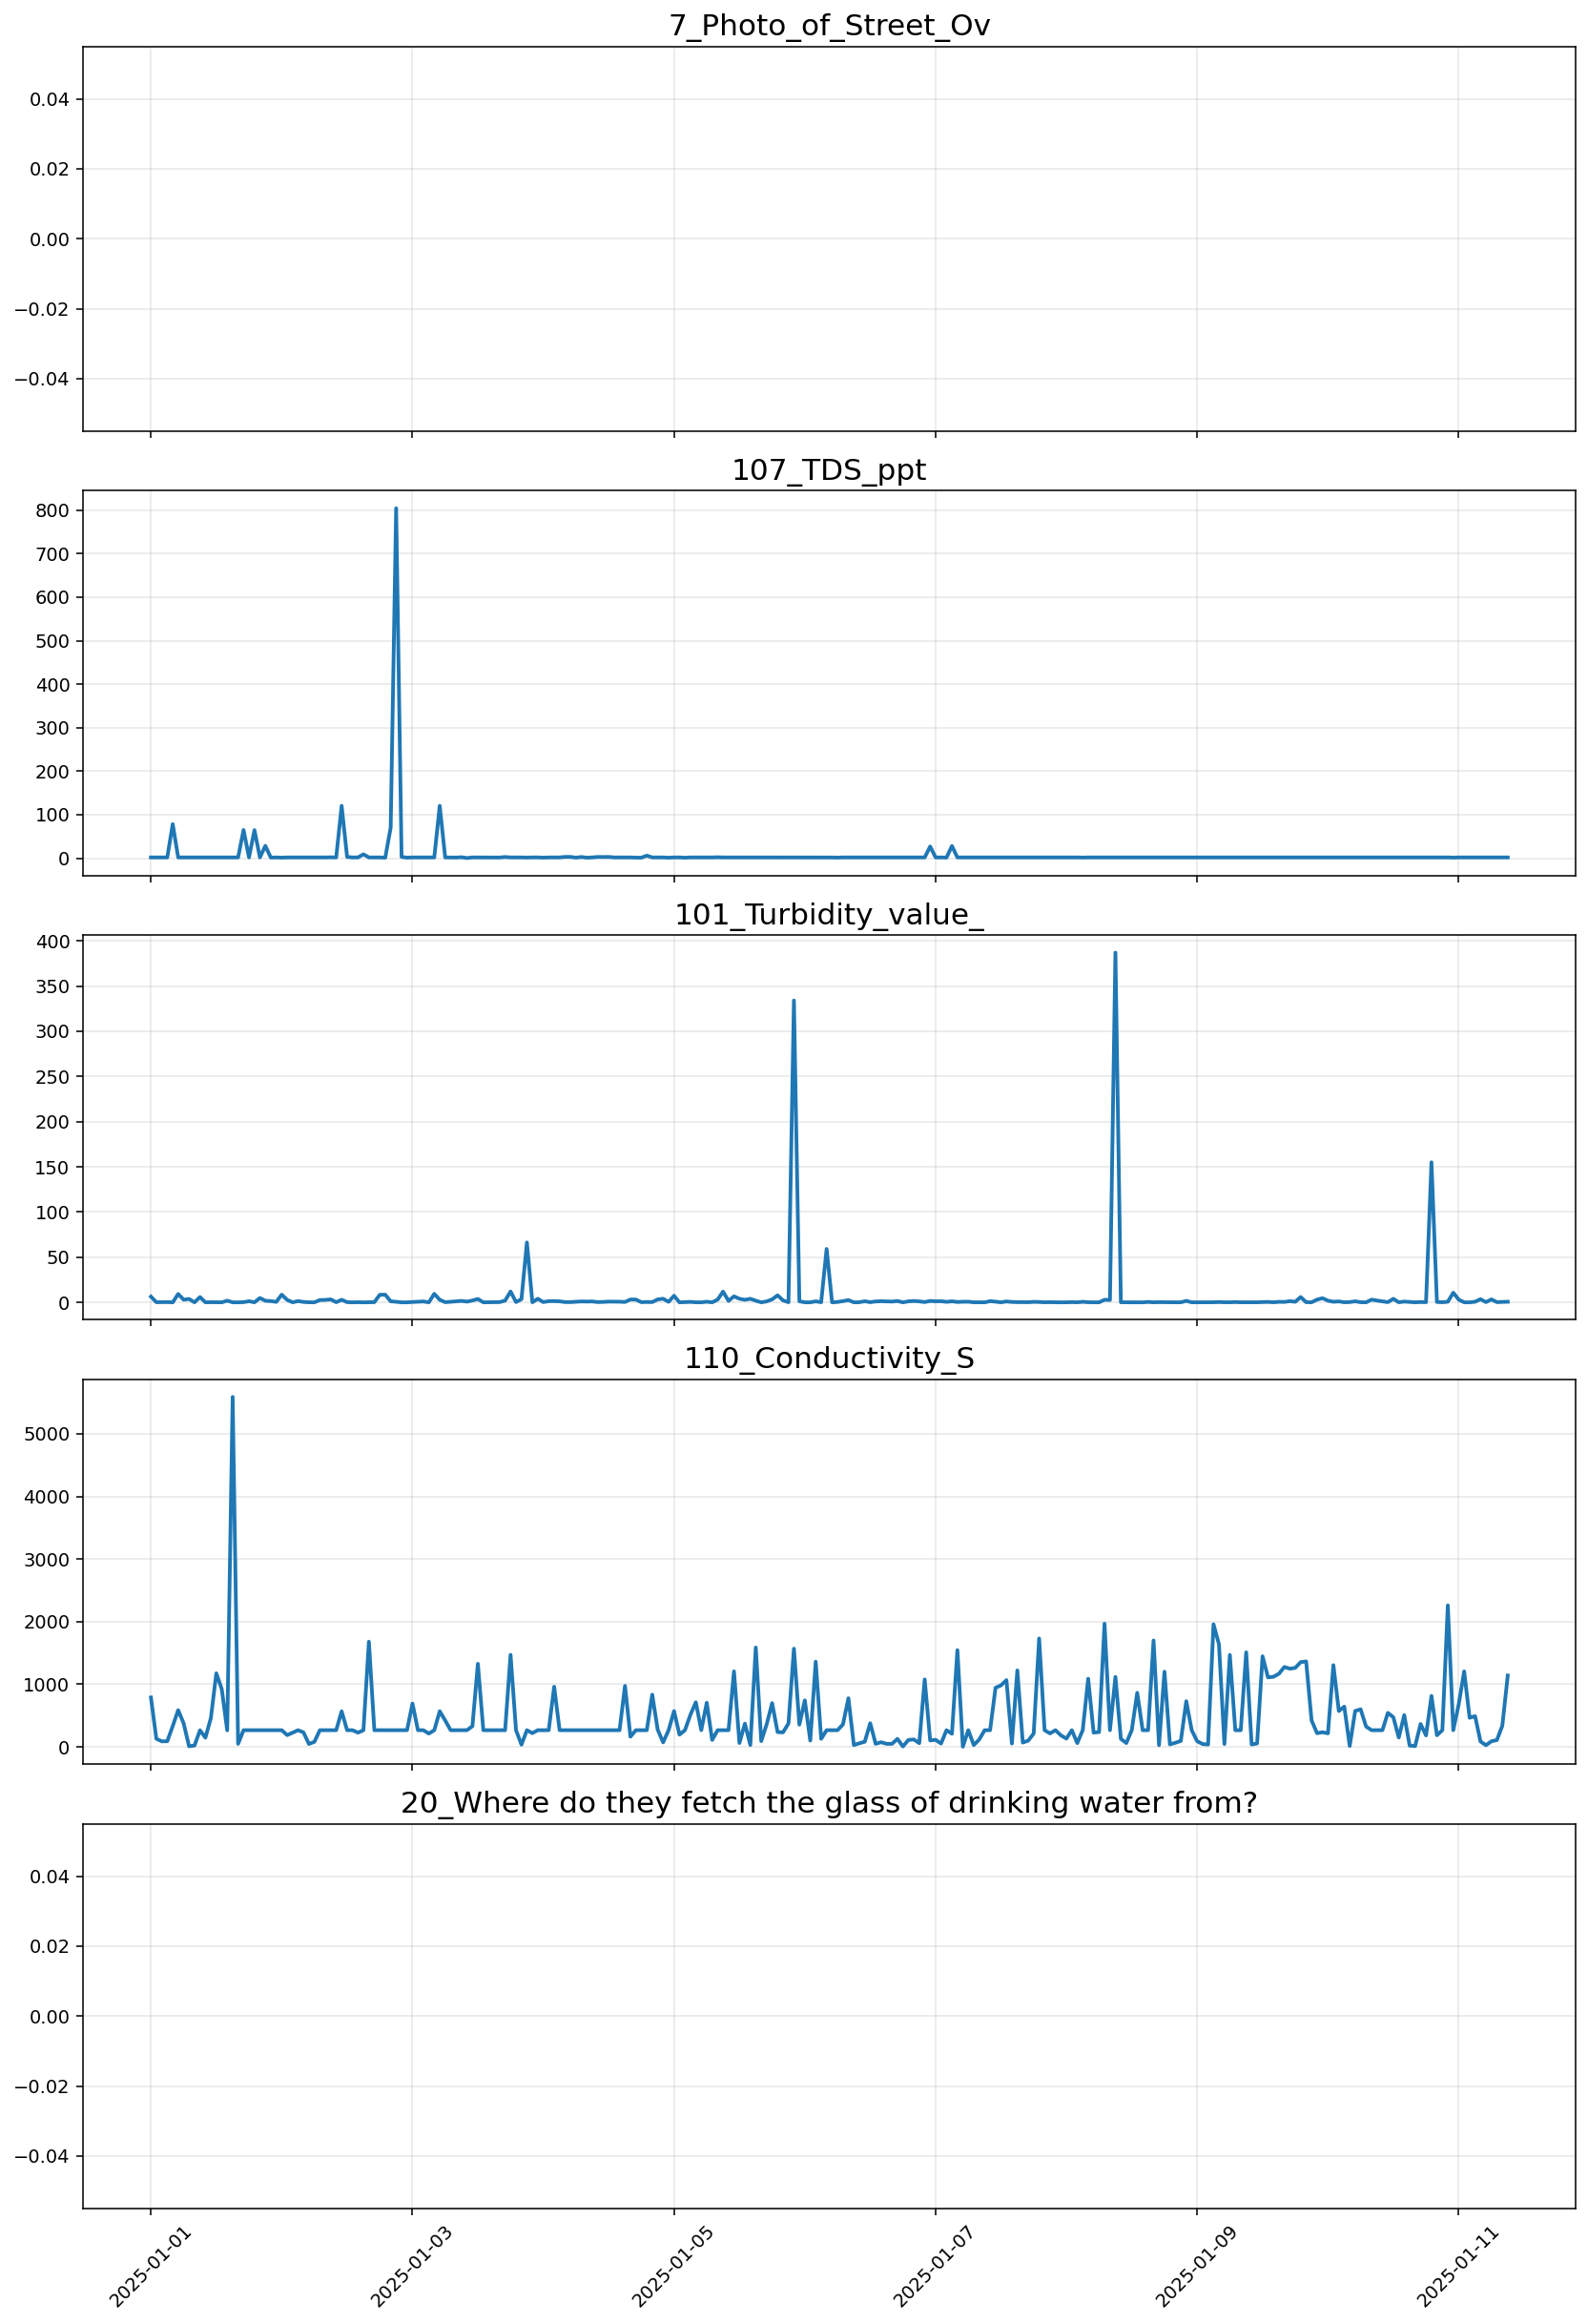

In [51]:
# Step 3 — SAFE Plot (Fix Error Completely)
if "timestamp" not in df.columns:
    df["timestamp"] = pd.date_range(start="2025-01-01", periods=len(df), freq="h")

available_params = [
    p for p in available_params
    if isinstance(p, str) and p in df.columns
]

if len(available_params) == 0:
    print("No valid matched columns found.")
else:
    n = len(available_params)
    fig, axes = plt.subplots(n, 1, figsize=(12, 3.5 * n), sharex=True)

    if n == 1:
        axes = [axes]

    for i, param in enumerate(available_params):
        y = pd.to_numeric(df[param], errors="coerce")
        axes[i].plot(df["timestamp"], y, linewidth=2)
        axes[i].set_title(param)
        axes[i].grid(alpha=0.3)

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [52]:
print("available_params:", available_params)
print([type(x) for x in available_params])

available_params: ['7_Photo_of_Street_Ov', '107_TDS_ppt', '101_Turbidity_value_', '110_Conductivity_S', '20_Where do they fetch the glass of drinking water from?']
[<class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>]


Matched columns:
pH: 7_Photo_of_Street_Ov
TDS: 107_TDS_ppt
Turbidity: 101_Turbidity_value_
Conductivity: 110_Conductivity_S
DO: 20_Where do they fetch the glass of drinking water from?
Temperature: None


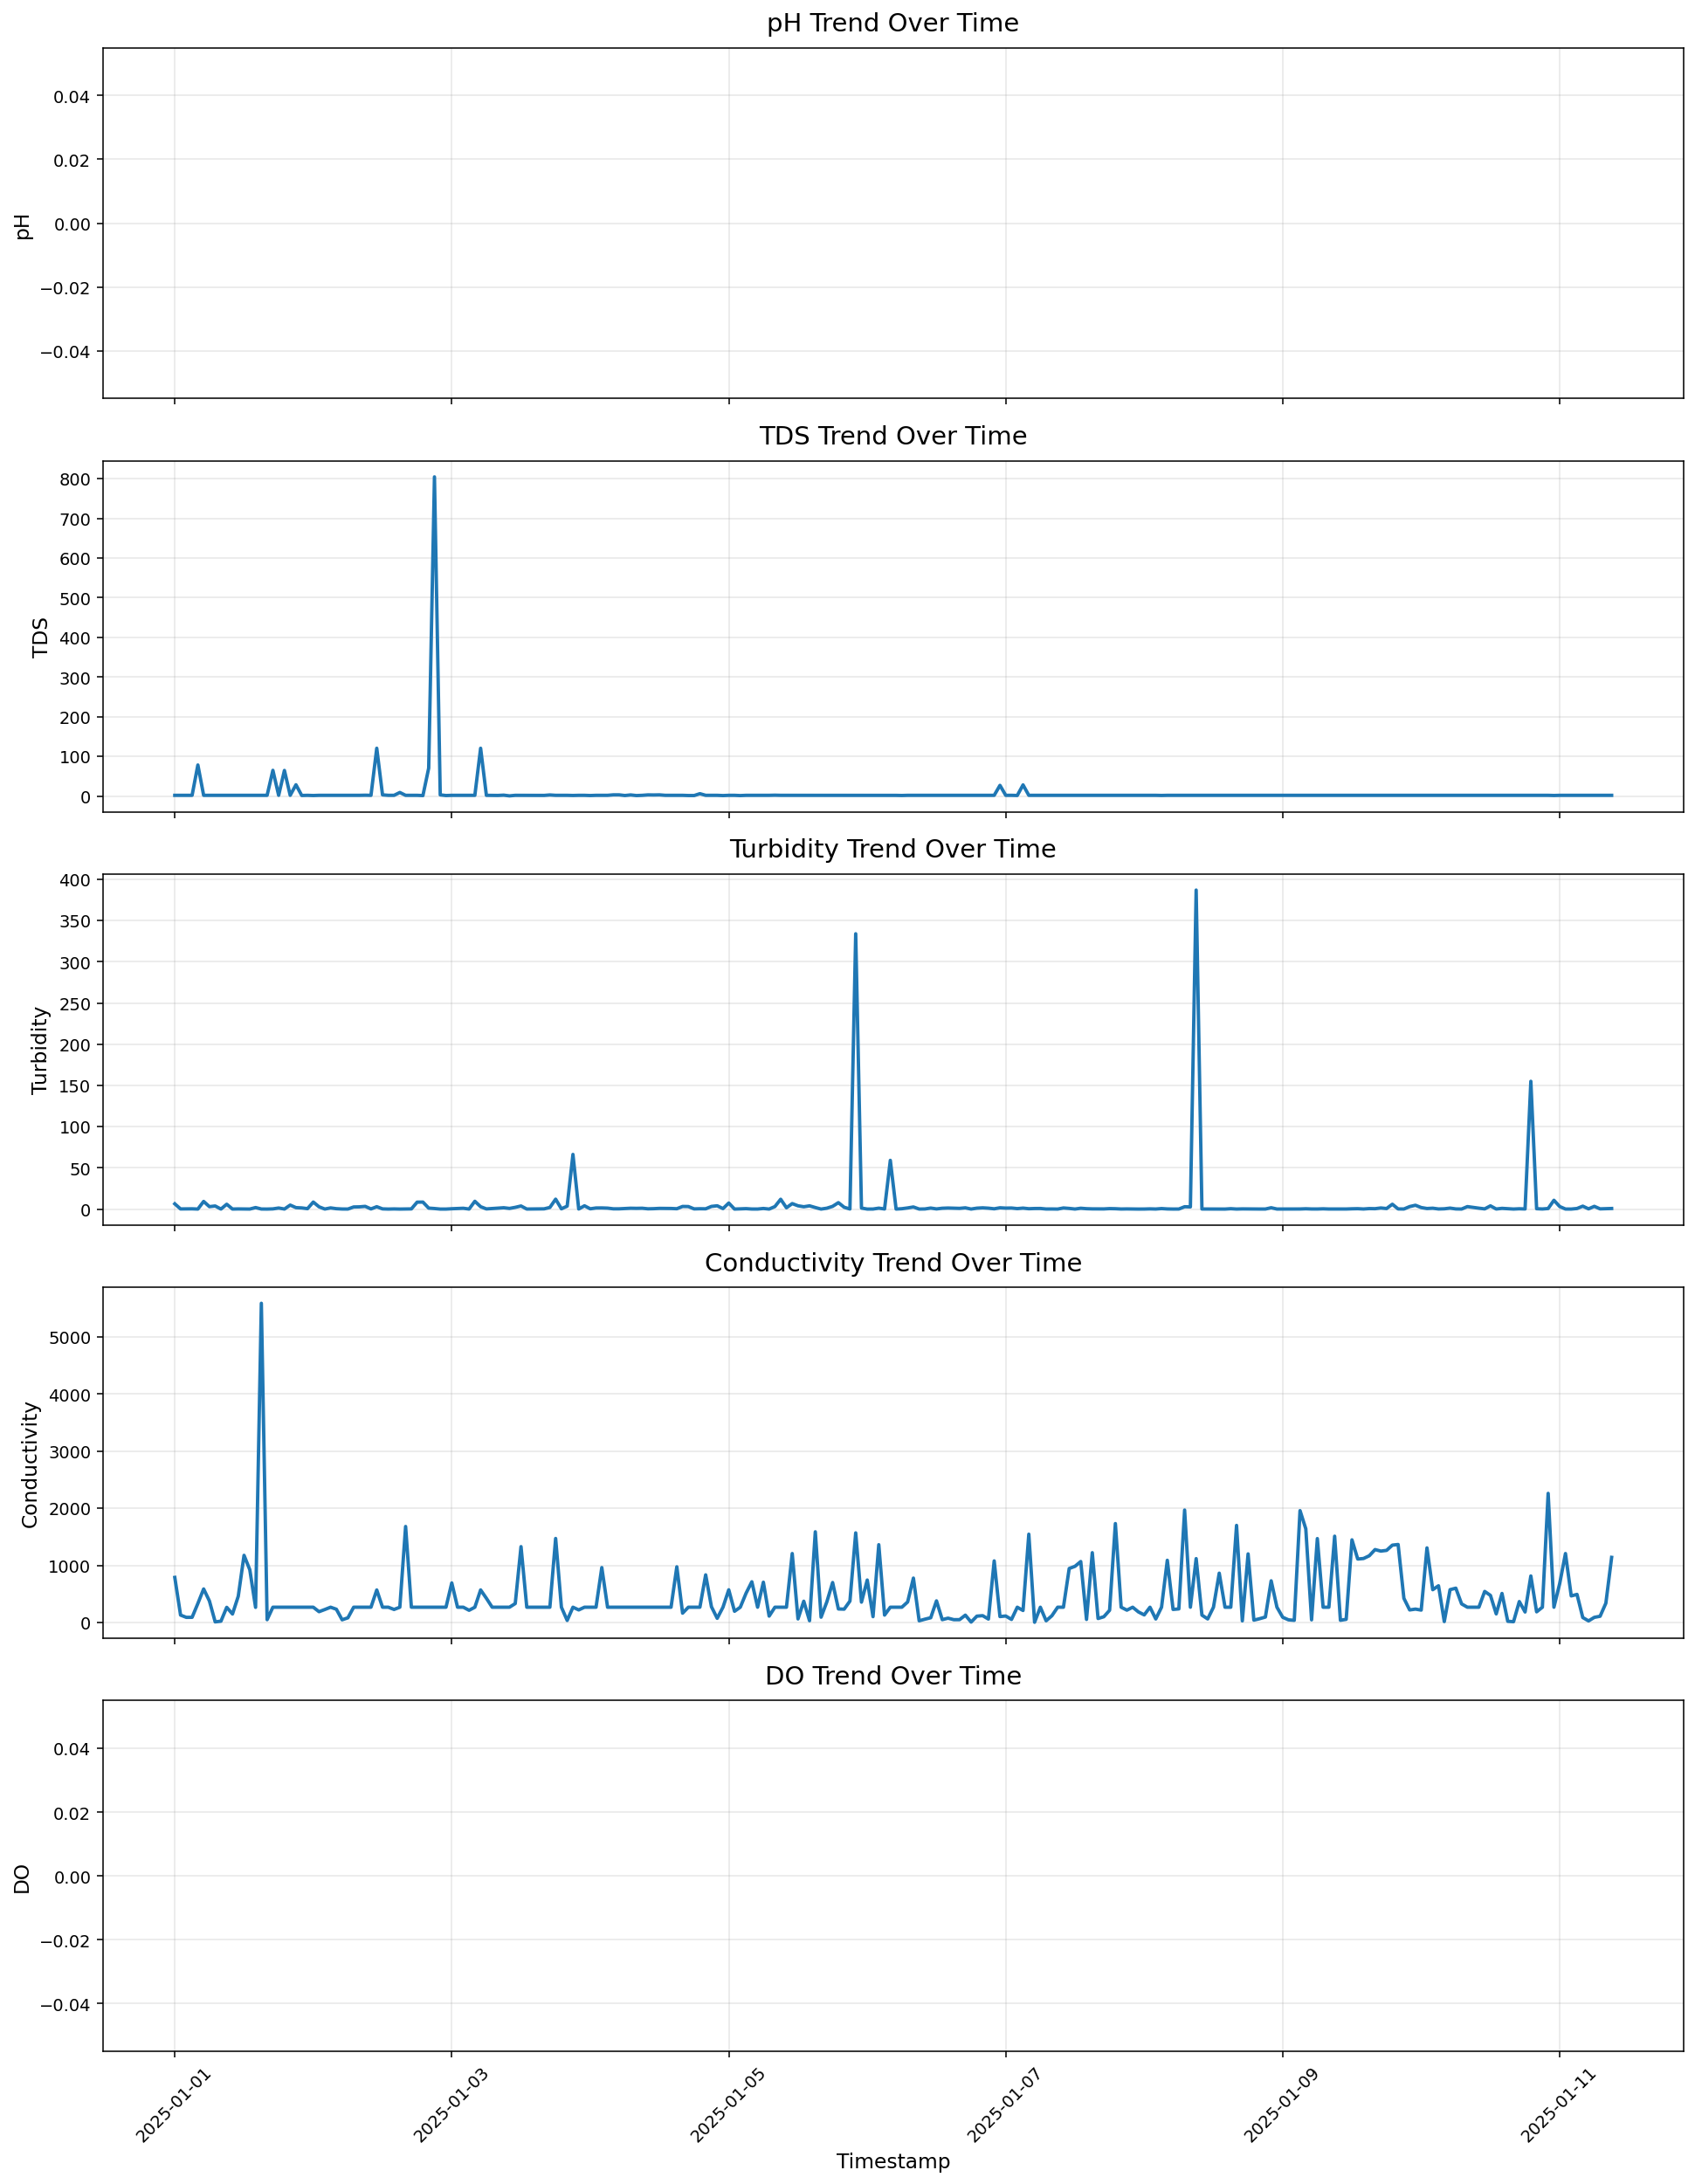

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------
# Ensure timestamp exists
# -------------------------------------------------
if "timestamp" not in df.columns:
    df["timestamp"] = pd.date_range(start="2025-01-01", periods=len(df), freq="h")

# -------------------------------------------------
# Map likely core water parameter columns
# Adjust keyword matching if needed
# -------------------------------------------------
keywords = {
    "pH": ["ph"],
    "TDS": ["tds"],
    "Turbidity": ["turb"],
    "Conductivity": ["cond"],
    "DO": ["do", "dissolved oxygen"],
    "Temperature": ["temp", "temperature"]
}

matched_cols = {}

for label, keys in keywords.items():
    found = None
    for col in df.columns:
        col_str = str(col).lower()
        if any(k in col_str for k in keys):
            found = col
            break
    matched_cols[label] = found

print("Matched columns:")
for k, v in matched_cols.items():
    print(f"{k}: {v}")

# -------------------------------------------------
# Keep only valid columns
# -------------------------------------------------
plot_items = [
    (label, col)
    for label, col in matched_cols.items()
    if isinstance(col, str) and col in df.columns
]

if len(plot_items) == 0:
    print("No valid core water parameter columns found in the dataset.")
else:
    # -------------------------------------------------
    # Aesthetic settings
    # -------------------------------------------------
    plt.rcParams.update({
        "figure.dpi": 140,
        "savefig.dpi": 300,
        "axes.titlesize": 15,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "font.size": 11
    })

    n = len(plot_items)
    fig, axes = plt.subplots(n, 1, figsize=(14, 3.6 * n), sharex=True)

    if n == 1:
        axes = [axes]

    for i, (label, col) in enumerate(plot_items):
        y = pd.to_numeric(df[col], errors="coerce")

        axes[i].plot(
            df["timestamp"],
            y,
            linewidth=2
        )

        axes[i].set_title(f"{label} Trend Over Time", pad=10)
        axes[i].set_ylabel(label)
        axes[i].grid(alpha=0.3)

    axes[-1].set_xlabel("Timestamp")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [54]:
import pandas as pd
import numpy as np

# ---------------------------
# 1. Standardize column names
# ---------------------------
df.columns = [str(c).strip().replace(" ", "_") for c in df.columns]

# ---------------------------
# 2. Replace common invalid values
# ---------------------------
df.replace(["NA", "N/A", "-", "", "null", "None"], np.nan, inplace=True)

# ---------------------------
# 3. Convert all possible numeric columns
# ---------------------------
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="ignore")

# ---------------------------
# 4. Detect numeric & categorical
# ---------------------------
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include="object").columns.tolist()

print("Numeric cols:", len(numeric_cols))
print("Categorical cols:", len(categorical_cols))

# ---------------------------
# 5. Drop useless columns (all null)
# ---------------------------
df = df.dropna(axis=1, how="all")

# ---------------------------
# 6. Handle low-quality columns
# Drop columns with >60% missing
# ---------------------------
threshold = 0.6
missing_ratio = df.isnull().mean()

cols_to_drop = missing_ratio[missing_ratio > threshold].index.tolist()

df = df.drop(columns=cols_to_drop)

print("Dropped columns:", len(cols_to_drop))

# ---------------------------
# 7. IMPUTATION
# ---------------------------

imputation_log = []

# Numeric → median
for col in numeric_cols:
    if col in df.columns:
        missing = df[col].isnull().sum()
        if missing > 0:
            median_val = df[col].median()

            if pd.isna(median_val):
                df[col] = df[col].fillna(0)
                strategy = "Filled with 0"
            else:
                df[col] = df[col].fillna(median_val)
                strategy = f"Median ({round(median_val,2)})"

            imputation_log.append((col, missing, strategy))

# Categorical → mode
for col in categorical_cols:
    if col in df.columns:
        missing = df[col].isnull().sum()
        if missing > 0:
            mode_series = df[col].mode()

            if not mode_series.empty:
                df[col] = df[col].fillna(mode_series.iloc[0])
                strategy = f"Mode ({mode_series.iloc[0]})"
            else:
                df[col] = df[col].fillna("Unknown")
                strategy = "Unknown"

            imputation_log.append((col, missing, strategy))

# ---------------------------
# 8. Final validation
# ---------------------------
print("\nRemaining missing values:", df.isnull().sum().sum())

imputation_df = pd.DataFrame(imputation_log, columns=["Column", "Missing Count", "Strategy"])
print("\nImputation Summary:")
print(imputation_df.head(20))

print("\nFinal Dataset Shape:", df.shape)

/tmp/ipykernel_2760/886851733.py:18: FutureWarning:

errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead



Numeric cols: 22
Categorical cols: 118
Dropped columns: 30

Remaining missing values: 0

Imputation Summary:
                                               Column  Missing Count  \
0                       UTM_Zone_2_Location_Click_Upd              2   
1                                7_Photo_of_Street_Ov            119   
2                                8_Photo_of_House_and            133   
3                                9_Photo_of_House_Gat            148   
4                              10__Name_of_respondent            102   
5                                    11_Mobile_Number            103   
6                                           13_Gender            102   
7                                        14_Age_Group            102   
8                          15_Position_in_your_family            102   
9                16_Highest_educational_qualification            102   
10                      18_Time_(Autoset;_click_next)            102   
11                      19_

Top numeric columns selected for plotting:
['timestamp', 'UTM_Northing_2_Location_Click_Upd', 'UTM_Easting_2_Location_Click_Upd', '110_Conductivity_S', '108_TDS_ppm', '98_Hardness_mgL', 'accuracy_2_Location_Click_Upd', '105_ORP_mV', '111_Conductivity_mS', '99_Alkalinity_ppm', '107_TDS_ppt', '102_Turbidity_value_', '101_Turbidity_value_', '103_Turbidity_AVG_NT', '17_Number_of_children_under_the_age_of_5_in_your_home', 'long_2_Location_Click_Upd', 'lat_2_Location_Click_Upd', '104_pH', '96_Total_Chlorine_mg', '100_pH', '97_Free_Chlorine_mgL']


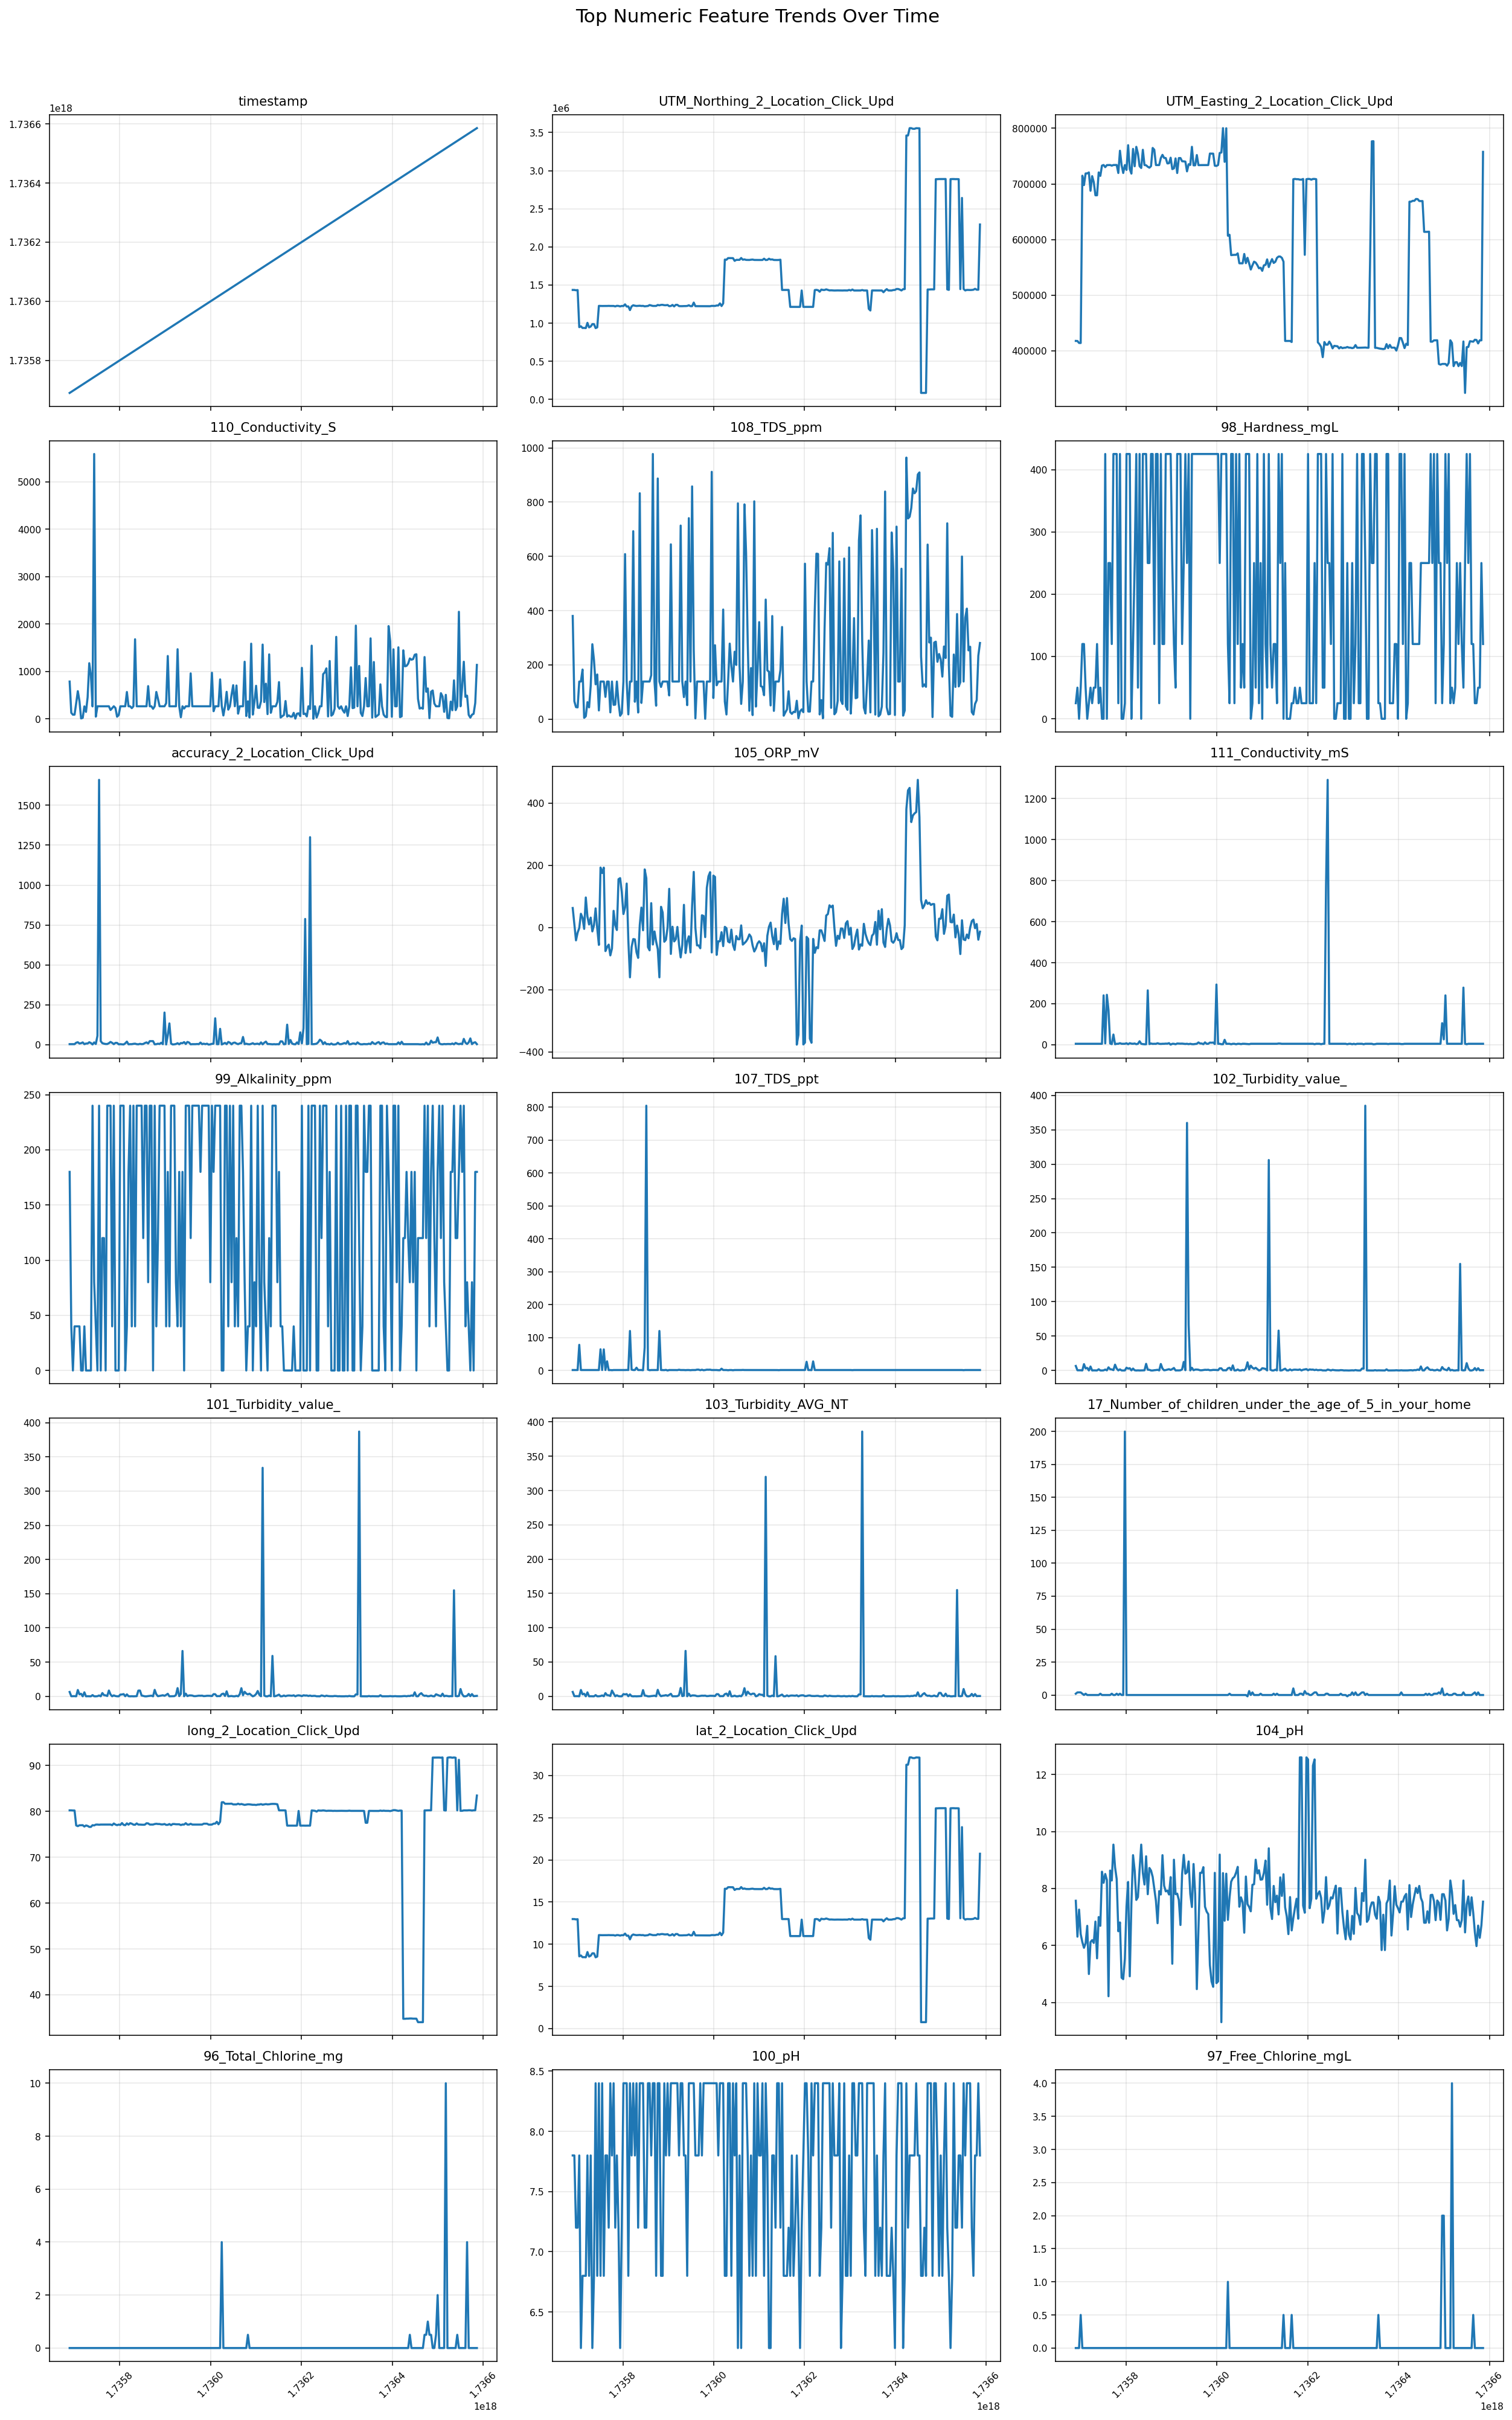

In [57]:
import math
import pandas as pd
import matplotlib.pyplot as plt

# Numeric-only dataframe from cleaned/imputed df
df_numeric = df.select_dtypes(include="number").copy()
df_numeric = df_numeric.dropna(axis=1, how="all")

if "timestamp" not in df.columns:
    df["timestamp"] = pd.date_range(start="2025-01-01", periods=len(df), freq="h")

# Keep numeric columns with actual values
valid_numeric_cols = [
    col for col in df_numeric.columns
    if pd.to_numeric(df_numeric[col], errors="coerce").notna().sum() > 0
]

# Rank by variance to surface informative plots
variance_ranked = (
    df_numeric[valid_numeric_cols]
    .var(numeric_only=True)
    .sort_values(ascending=False)
)

top_n = 24
plot_cols = variance_ranked.head(top_n).index.tolist()

print("Top numeric columns selected for plotting:")
print(plot_cols)

if len(plot_cols) == 0:
    print("No numeric columns available for plotting.")
else:
    n = len(plot_cols)
    ncols = 3
    nrows = math.ceil(n / ncols)

    plt.rcParams.update({
        "figure.dpi": 140,
        "savefig.dpi": 300,
        "axes.titlesize": 11,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "font.size": 9
    })

    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows), sharex=True)
    axes = axes.flatten()

    for i, col in enumerate(plot_cols):
        y = pd.to_numeric(df_numeric[col], errors="coerce")

        axes[i].plot(df["timestamp"], y, linewidth=1.8)
        axes[i].set_title(col, pad=8)
        axes[i].grid(alpha=0.3)

    for j in range(len(plot_cols), len(axes)):
        axes[j].axis("off")

    for ax in axes[:len(plot_cols)]:
        ax.tick_params(axis="x", rotation=45)

    fig.suptitle("Top Numeric Feature Trends Over Time", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

👉 df_numeric + Location → Latitude/Longitude → Map

In [58]:
# First — Check if You Have Any Location Column

possible_location_cols = [
    col for col in df.columns
    if any(k in str(col).lower() for k in ["location", "source", "area", "site", "hostel", "mess", "restaurant"])
]

print("Detected location-related columns:", possible_location_cols)

Detected location-related columns: ['lat_2_Location_Click_Upd', 'long_2_Location_Click_Upd', 'accuracy_2_Location_Click_Upd', 'UTM_Northing_2_Location_Click_Upd', 'UTM_Easting_2_Location_Click_Upd', 'UTM_Zone_2_Location_Click_Upd', '80_Utilization_purposes_of_this_water_source(Empty)']


Use real lat/long in df_numeric

Step 1: add cleaned location columns

In [74]:
import plotly.express as px
# =========================================================
# STEP 1: Extract and clean location data
# =========================================================

lat_col = "lat_2_Location_Click_Upd"
lon_col = "long_2_Location_Click_Upd"
acc_col = "accuracy_2_Location_Click_Upd"

# Build numeric dataset from cleaned/imputed df
df_numeric = df.select_dtypes(include="number").copy()

# Add location columns from original cleaned df
df_numeric["latitude"] = pd.to_numeric(df[lat_col], errors="coerce")
df_numeric["longitude"] = pd.to_numeric(df[lon_col], errors="coerce")
df_numeric["gps_accuracy"] = pd.to_numeric(df[acc_col], errors="coerce")

Step 2: clean invalid coordinates

This removes impossible latitude/longitude values.

In [75]:
# =========================================================
# STEP 2: Validate coordinates
# =========================================================

df_numeric.loc[~df_numeric["latitude"].between(-90, 90), "latitude"] = np.nan
df_numeric.loc[~df_numeric["longitude"].between(-180, 180), "longitude"] = np.nan

# Impute missing coordinate values
df_numeric["latitude"] = df_numeric["latitude"].fillna(df_numeric["latitude"].median())
df_numeric["longitude"] = df_numeric["longitude"].fillna(df_numeric["longitude"].median())
df_numeric["gps_accuracy"] = df_numeric["gps_accuracy"].fillna(df_numeric["gps_accuracy"].median())

Step 3: impute missing location values properly

Since these are real GPS fields, the safest simple approach is median imputation.

In [76]:
# =========================================================
# STEP 2: Validate coordinates
# =========================================================

df_numeric.loc[~df_numeric["latitude"].between(-90, 90), "latitude"] = np.nan
df_numeric.loc[~df_numeric["longitude"].between(-180, 180), "longitude"] = np.nan

# Impute missing coordinate values
df_numeric["latitude"] = df_numeric["latitude"].fillna(df_numeric["latitude"].median())
df_numeric["longitude"] = df_numeric["longitude"].fillna(df_numeric["longitude"].median())
df_numeric["gps_accuracy"] = df_numeric["gps_accuracy"].fillna(df_numeric["gps_accuracy"].median())

# =========================================================
# STEP 4: Create labels
# =========================================================

In [77]:
# =========================================================
# STEP 4: Labels
# =========================================================

df_map["label"] = [f"S{i+1}" for i in range(len(df_map))]

Step 5: plot map with contrast colors and visible labels

Use a strong numeric field for color. If you already created WQI, use that. Otherwise use another meaningful numeric field.

In [78]:
# =========================================================
# STEP 5: Choose color column
# =========================================================

preferred_cols = ["WQI", "WQI_Simple", "TDS", "Conductivity", "Turbidity", "pH", "Temperature"]

color_col = None
for c in preferred_cols:
    if c in df_map.columns:
        color_col = c
        break

if color_col is None:
    numeric_candidates = [c for c in df_map.columns if c not in ["latitude", "longitude", "gps_accuracy"]]
    color_col = numeric_candidates[0]

print("Coloring map using:", color_col)

# If the color column has nulls, fill for display stability
df_map[color_col] = pd.to_numeric(df_map[color_col], errors="coerce")
df_map[color_col] = df_map[color_col].fillna(df_map[color_col].median())

Coloring map using: lat_2_Location_Click_Upd


In [80]:
# =========================================================
# STEP 6: Plot map
# =========================================================

fig = px.scatter_map(
    df_map,
    lat="latitude",
    lon="longitude",
    color=color_col,
    size=color_col,
    size_max=18,
    text="label",
    hover_name="label",
    hover_data={
        "latitude": True,
        "longitude": True,
        "gps_accuracy": True,
        color_col: True
    },
    zoom=10,
    title=f"Water Quality Map (Colored by {color_col})",
    color_continuous_scale="Turbo"
)


In [81]:
# =========================================================
# STEP 7: Safe trace updates
# =========================================================

fig.update_traces(
    opacity=0.95,
    textposition="top center"
)


In [83]:
# =========================================================
# STEP 8: Layout styling
# =========================================================

fig.update_layout(
    template="plotly_dark",
    title_x=0.5,
    width=1150,
    height=780,
    coloraxis_colorbar=dict(
        title=color_col,
        thickness=22,
        len=0.75
    ),
    margin=dict(l=20, r=20, t=60, b=20)
)

fig.show()

In [101]:
# Show columns that may be water-quality related
keywords = [
    "ph", "tds", "turb", "cond", "conduct", "do", "oxygen",
    "temp", "temperature", "quality", "wqi", "water"
]

candidate_cols = [
    col for col in df.columns
    if any(k in str(col).lower() for k in keywords)
]

print("Candidate water-quality columns:")
for col in candidate_cols:
    print(col)

Candidate water-quality columns:
6_Type_of_Water_Samp
7_Photo_of_Street_Ov
8_Photo_of_House_and
9_Photo_of_House_Gat
20_Where_do_they_fetch_the_glass_of_drinking_water_from?
23_Specify_the_type_of_container_from_which_they_fetch_water
24_Did_the_respondent_fingers_touch_the_water_while_they_are_taking_water?
25_How_they_fetched_the_water_from_the_container
29_Do_you_wash_the_dedicated_cup?
30_How_often_do_you_wash_the_dedicated_cup?
31_Was_the_drinking_water_ever_stored_in_a_container?
38_When_did_you_last_boiled_water?
42_Do_you_use_different_types_of_water_for_drinking_and_bathing?
43_How_does_your_household_get_its_drinking_water_supply?
49__Has_your_drinking_water_stored_in_a_roof_tank?
53_Do_you_treat_your_water_in_anyway?
70_Please_take_a_cup_of_your_drinking_water,_what_is_the_color?
71_What_does_your_drinking_water_taste_like?
72_What_does_your_drinking_water_smell_like?
73_How_do_you_feel_about_the_safety_of_this_water?
74_What_is_the_risk_of_becoming_ill_by_consuming_your_wat

In [104]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# =========================================================
# 1. Build map-ready dataframe
# =========================================================

lat_col = "lat_2_Location_Click_Upd"
lon_col = "long_2_Location_Click_Upd"
acc_col = "accuracy_2_Location_Click_Upd"

df_map = df.copy()

df_map["latitude"] = pd.to_numeric(df_map[lat_col], errors="coerce")
df_map["longitude"] = pd.to_numeric(df_map[lon_col], errors="coerce")
df_map["gps_accuracy"] = pd.to_numeric(df_map[acc_col], errors="coerce")

# Clean coordinates
df_map.loc[~df_map["latitude"].between(-90, 90), "latitude"] = np.nan
df_map.loc[~df_map["longitude"].between(-180, 180), "longitude"] = np.nan

df_map["latitude"] = df_map["latitude"].fillna(df_map["latitude"].median())
df_map["longitude"] = df_map["longitude"].fillna(df_map["longitude"].median())
df_map["gps_accuracy"] = df_map["gps_accuracy"].fillna(df_map["gps_accuracy"].median())

# Optional GPS filter
df_map = df_map[df_map["gps_accuracy"] <= 100].copy()
if len(df_map) == 0:
    df_map = df.copy()
    df_map["latitude"] = pd.to_numeric(df_map[lat_col], errors="coerce")
    df_map["longitude"] = pd.to_numeric(df_map[lon_col], errors="coerce")
    df_map["gps_accuracy"] = pd.to_numeric(df_map[acc_col], errors="coerce")
    df_map["latitude"] = df_map["latitude"].fillna(df_map["latitude"].median())
    df_map["longitude"] = df_map["longitude"].fillna(df_map["longitude"].median())
    df_map["gps_accuracy"] = df_map["gps_accuracy"].fillna(df_map["gps_accuracy"].median())

df_map["Sample_ID"] = [f"S{i+1}" for i in range(len(df_map))]

# =========================================================
# 2. Detect candidate water-quality parameters
# =========================================================

excluded_cols = {
    lat_col, lon_col, acc_col,
    "latitude", "longitude", "gps_accuracy",
    "UTM_Northing_2_Location_Click_Upd",
    "UTM_Easting_2_Location_Click_Upd",
    "UTM_Zone_2_Location_Click_Upd"
}

numeric_cols = [
    c for c in df_map.select_dtypes(include="number").columns
    if c not in excluded_cols
]

priority_keywords = [
    "wqi", "quality", "tds", "ph", "turb", "conduct", "cond",
    "oxygen", "do", "temp", "temperature", "water"
]

ranked_candidates = []
for col in numeric_cols:
    col_l = str(col).lower()
    score = 0
    for i, kw in enumerate(priority_keywords):
        if kw in col_l:
            score += (len(priority_keywords) - i)
    if score > 0:
        ranked_candidates.append((col, score))

ranked_candidates = sorted(ranked_candidates, key=lambda x: x[1], reverse=True)
candidate_params = [c for c, _ in ranked_candidates]

# fallback
if len(candidate_params) == 0:
    variance_ranked = df_map[numeric_cols].var(numeric_only=True).sort_values(ascending=False)
    candidate_params = variance_ranked.head(10).index.tolist()

print("Candidate parameters:")
for c in candidate_params:
    print("-", c)

# =========================================================
# 3. Label only a subset
# =========================================================

label_count = 25
label_idx = np.linspace(0, len(df_map) - 1, min(label_count, len(df_map)), dtype=int)

df_map["label_text"] = ""
df_map.iloc[label_idx, df_map.columns.get_loc("label_text")] = df_map.iloc[label_idx]["Sample_ID"]

# =========================================================
# 4. Helper functions
# =========================================================

def clean_numeric(series):
    s = pd.to_numeric(series, errors="coerce")
    s = s.fillna(s.median())
    return s

def make_size_safe(series):
    s = clean_numeric(series)
    s = s - s.min()
    s = s + 1
    return s

def make_hover_text(df_in, param):
    s = clean_numeric(df_in[param])
    return (
        "Sample: " + df_in["Sample_ID"].astype(str) + "<br>" +
        "Latitude: " + df_in["latitude"].round(6).astype(str) + "<br>" +
        "Longitude: " + df_in["longitude"].round(6).astype(str) + "<br>" +
        "GPS Accuracy: " + df_in["gps_accuracy"].round(2).astype(str) + "<br>" +
        f"{param}: " + s.round(3).astype(str)
    )

# =========================================================
# 5. Initial parameter
# =========================================================

initial_param = candidate_params[0]
initial_series = clean_numeric(df_map[initial_param])
initial_size = make_size_safe(df_map[initial_param])
initial_hover = make_hover_text(df_map, initial_param)

# =========================================================
# 6. Build figure
# =========================================================

fig = go.Figure()

# Main points
fig.add_trace(go.Scattermapbox(
    lat=df_map["latitude"],
    lon=df_map["longitude"],
    mode="markers",
    hovertext=initial_hover,
    hoverinfo="text",
    marker=dict(
        size=initial_size,
        sizemode="diameter",
        sizemin=6,
        color=initial_series,
        colorscale="Plasma",
        cmin=initial_series.min(),
        cmax=initial_series.max(),
        opacity=0.88,
        showscale=True,
        colorbar=dict(
            title=dict(text=f"Water Quality ({initial_param})"),
            thickness=22,
            len=0.75,
            x=1.02
        )
    ),
    name="All Samples"
))

# Labeled subset
fig.add_trace(go.Scattermapbox(
    lat=df_map.iloc[label_idx]["latitude"],
    lon=df_map.iloc[label_idx]["longitude"],
    mode="markers+text",
    text=df_map.iloc[label_idx]["label_text"],
    textposition="top right",
    textfont=dict(size=11, color="black"),
    hoverinfo="skip",
    marker=dict(
        size=14,
        color="black",
        opacity=0.95
    ),
    name="Labeled Samples"
))

# =========================================================
# 7. Dropdown buttons
# =========================================================

buttons = []

for param in candidate_params:
    series = clean_numeric(df_map[param])
    size_safe = make_size_safe(df_map[param])
    hover_text = make_hover_text(df_map, param)

    buttons.append(
        dict(
            label=param,
            method="update",
            args=[
                {
                    "marker.color": [series, None],
                    "marker.size": [size_safe, None],
                    "marker.cmin": [series.min(), None],
                    "marker.cmax": [series.max(), None],
                    "marker.colorbar.title.text": [f"Water Quality ({param})", None],
                    "hovertext": [hover_text, None]
                },
                {
                    "title.text": f"Water Quality Sample Locations — colored by {param}"
                }
            ]
        )
    )

# =========================================================
# 8. Layout
# =========================================================

fig.update_layout(
    mapbox=dict(
        style="carto-positron",
        zoom=9,
        center=dict(
            lat=df_map["latitude"].median(),
            lon=df_map["longitude"].median()
        )
    ),
    title=dict(
        text=f"Water Quality Sample Locations — colored by {initial_param}",
        x=0.5
    ),
    width=1280,
    height=840,
    margin=dict(l=20, r=60, t=90, b=20),
    paper_bgcolor="white",
    plot_bgcolor="white",
    font=dict(color="black", size=13),
    legend=dict(
        bgcolor="rgba(255,255,255,0.85)",
        bordercolor="black",
        borderwidth=1
    ),
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            showactive=True,
            x=0.02,
            xanchor="left",
            y=1.02,
            yanchor="top",
            bgcolor="white",
            bordercolor="black",
            borderwidth=1,
            font=dict(color="black", size=12)
        )
    ],
    annotations=[
        dict(
            text="Select Water Quality Parameter:",
            x=0.02,
            y=1.08,
            xref="paper",
            yref="paper",
            showarrow=False,
            font=dict(size=13, color="black")
        )
    ]
)

fig.show()

Candidate parameters:
- 110_Conductivity_S
- 111_Conductivity_mS
- 107_TDS_ppt
- 108_TDS_ppm
- 100_pH
- 104_pH
- 101_Turbidity_value_
- 102_Turbidity_value_
- 103_Turbidity_AVG_NT
